Accuracy: 0.9736842105263158

Confusion Matrix:
[[40  3]
 [ 0 71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



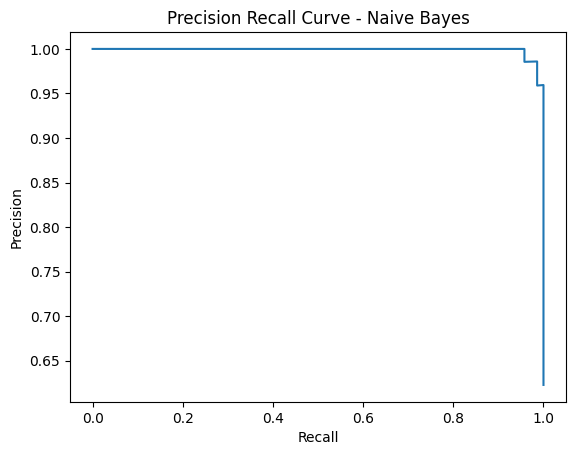

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Naive Bayes model
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

# Predictions
y_pred = model_nb.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Precision Recall Curve
y_scores = model_nb.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve - Naive Bayes")
plt.show()

Accuracy: 0.9473684210526315

Confusion Matrix:
[[40  3]
 [ 3 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



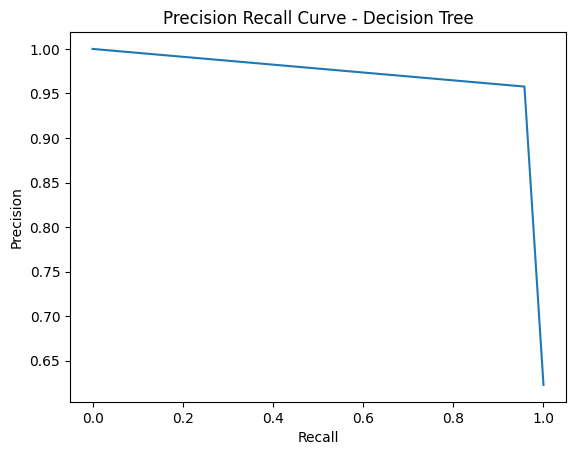

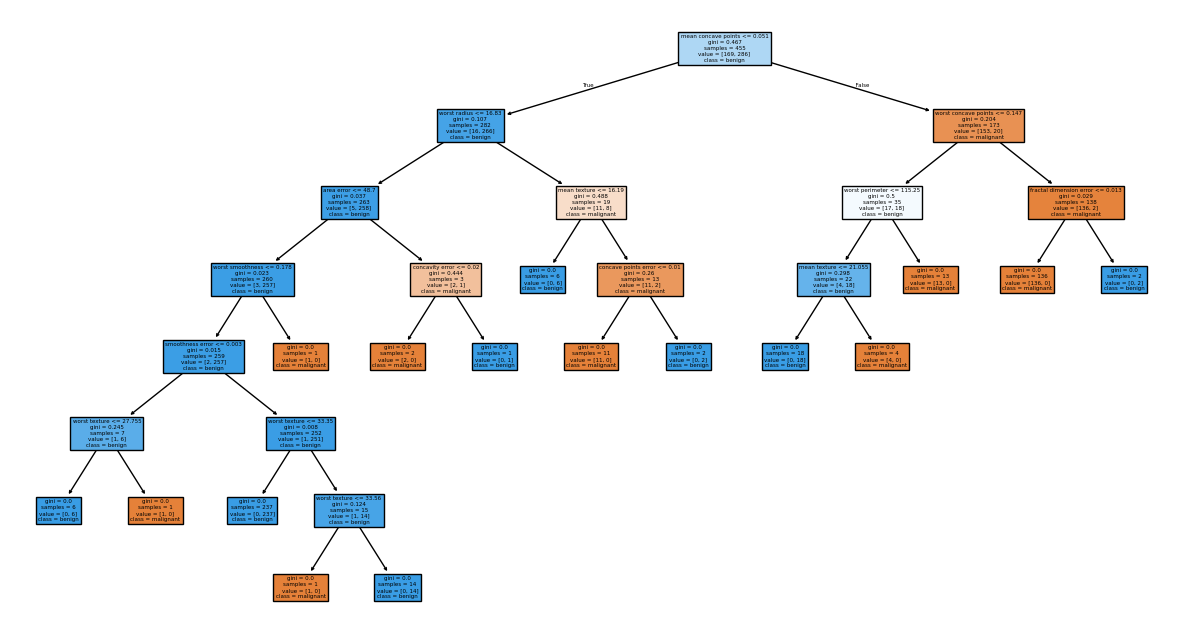

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Train Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train, y_train)

# Prediction
y_pred_dt = model_dt.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Precision Recall Curve
y_scores_dt = model_dt.predict_proba(X_test)[:,1]

precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_scores_dt)

plt.plot(recall_dt, precision_dt)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve - Decision Tree")
plt.show()

# Visualize Decision Tree
plt.figure(figsize=(15,8))
plot_tree(model_dt,
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True)

plt.show()

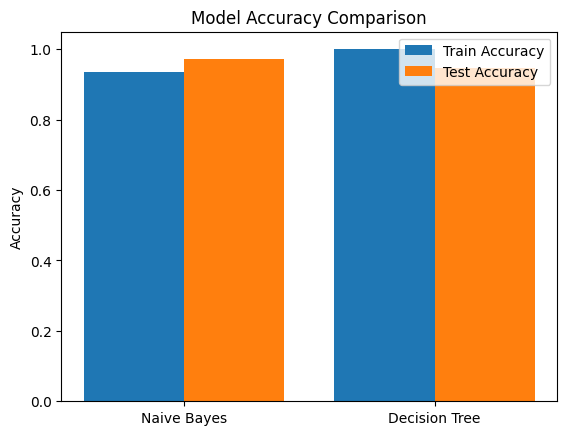

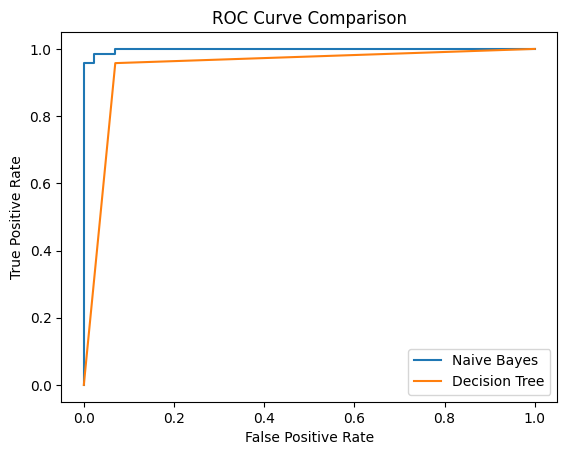

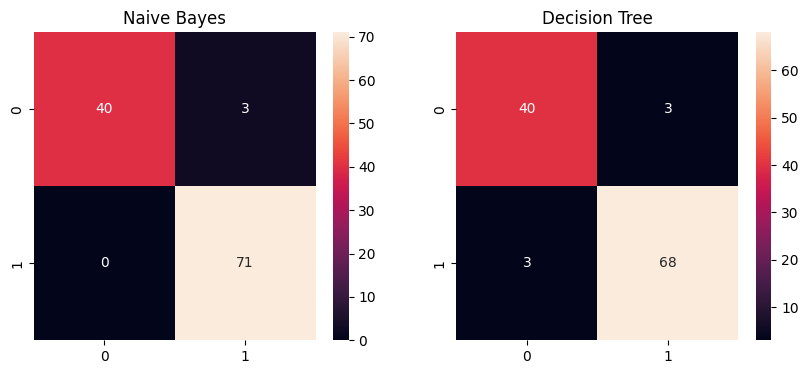

In [3]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Training accuracy
train_nb = model_nb.score(X_train, y_train)
test_nb = model_nb.score(X_test, y_test)

train_dt = model_dt.score(X_train, y_train)
test_dt = model_dt.score(X_test, y_test)

# Bar Chart comparison
models = ["Naive Bayes","Decision Tree"]
train_scores = [train_nb, train_dt]
test_scores = [test_nb, test_dt]

x = np.arange(len(models))

plt.bar(x-0.2, train_scores, width=0.4, label="Train Accuracy")
plt.bar(x+0.2, test_scores, width=0.4, label="Test Accuracy")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.legend()
plt.show()

# ROC Curve
fpr_nb, tpr_nb, _ = roc_curve(y_test, model_nb.predict_proba(X_test)[:,1])
fpr_dt, tpr_dt, _ = roc_curve(y_test, model_dt.predict_proba(X_test)[:,1])

plt.plot(fpr_nb, tpr_nb, label="Naive Bayes")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Confusion Matrix Heatmaps
fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt="d",
            ax=ax[0])

ax[0].set_title("Naive Bayes")

sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True,
            fmt="d",
            ax=ax[1])

ax[1].set_title("Decision Tree")

plt.show()